In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.
Path to dataset files: /kaggle/input/new-plant-diseases-dataset


In [ ]:
import os
os.listdir(f"{path}/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)")

['valid', 'train']

In [ ]:
train_dir = f"{path}/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
valid_dir = f"{path}/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"

In [ ]:
import pandas as pd

data = []

def load_data(train_dir):
 for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        for img in os.listdir(class_path):
            img_path = os.path.join(class_path, img)

            plant, disease = class_name.split("___")

            data.append({
                "image_path": img_path,
                "label": class_name
            })
 return data

train_df = pd.DataFrame(load_data(train_dir))

Enter index to show:100


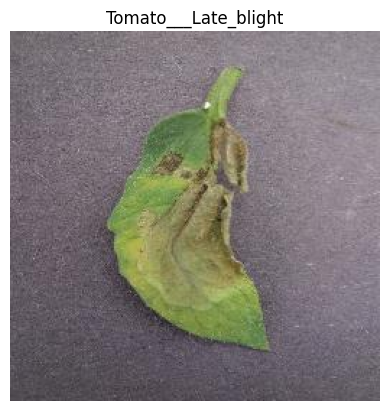

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
index = int(input("Enter index to show:"))
plt.title(train_df['label'][index])
plt.imshow(Image.open(train_df['image_path'][index]))
plt.axis('off')
plt.show()

In [ ]:
train_df['label'].value_counts()

,count
label,
Soybean___healthy,2022
Apple___Apple_scab,2016
Orange___Haunglongbing_(Citrus_greening),2010
Apple___healthy,2008
"Pepper,_bell___healthy",1988
Apple___Black_rot,1987
Tomato___Tomato_Yellow_Leaf_Curl_Virus,1961
Potato___Early_blight,1939
Potato___Late_blight,1939


In [ ]:
from sklearn.preprocessing import LabelEncoder

label = LabelEncoder()
train_df['label'] = label.fit_transform(train_df['label'])

In [ ]:
train_df

,image_path,label
0,/kaggle/input/new-plant-diseases-dataset/New P...,30
1,/kaggle/input/new-plant-diseases-dataset/New P...,30
2,/kaggle/input/new-plant-diseases-dataset/New P...,30
3,/kaggle/input/new-plant-diseases-dataset/New P...,30
4,/kaggle/input/new-plant-diseases-dataset/New P...,30
...,...,...
70290,/kaggle/input/new-plant-diseases-dataset/New P...,10
70291,/kaggle/input/new-plant-diseases-dataset/New P...,10
70292,/kaggle/input/new-plant-diseases-dataset/New P...,10
70293,/kaggle/input/new-plant-diseases-dataset/New P...,10


In [ ]:
import os
from PIL import Image
import torch
from torch.utils.data import Dataset , DataLoader

class DiseaseDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['image_path']
        label = self.df.iloc[idx]['label']
        label = torch.tensor(label)
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
from torchvision import transforms
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.ToTensor()
])

Enter index to show:100


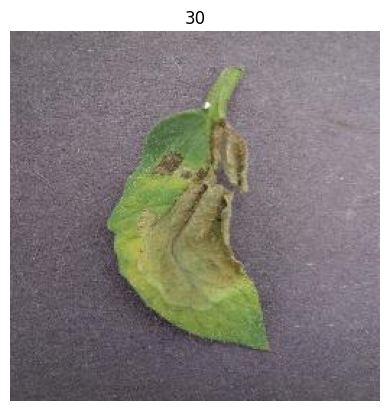

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
index = int(input("Enter index to show:"))
img = Image.open(train_df['image_path'][index]).convert("RGB")
img_transformed = transform(img)
img_np = img_transformed.permute(1, 2, 0).numpy()
plt.title(train_df['label'][index])
plt.imshow(img_np)
plt.axis('off')
plt.show()

In [ ]:
train_dataset = DiseaseDataset(train_df, transform)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [ ]:
from torchvision.models import densenet121
dense_net = densenet121(weights="DEFAULT")

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 195MB/s]


In [ ]:
import torch.nn as nn
import torch.optim as optim
for param in dense_net.features.parameters():
  param.requires_grad = False
  dense_net.classifier = nn.Sequential(
      nn.Linear(1024,512),
      nn.ReLU(),
      nn.Dropout(0.5),
      nn.Linear(512, 256),
      nn.ReLU(),
      nn.Dropout(0.5),
      nn.Linear(256,38)
  )

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dense_net = dense_net.to(device)
learning_rate = 0.0005
epochs = 5
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(dense_net.classifier.parameters(), lr = learning_rate)

In [ ]:
losses = []
for epoch in range(epochs):
    dense_net.train()
    train_loss = 0
    for images, labels in train_dataloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = dense_net(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_dataloader)
    losses.append(avg_train_loss)
    print(f"Epoch {epoch+1}: Train Loss={avg_train_loss:.4f}")

In [ ]:
import matplotlib.pyplot as plt
plt.plot(losses)
plt.plot(val_losses)
plt.show()